In [22]:
# DO NOT CONTAINERISE
# =====
# For debug
! pip list

# Analysis
# -----
# !pip install python-dotenv
# !pip install scikit-learn
# !pip install tensorflow
# !pip install keras


Package                   Version
------------------------- -----------
absl-py                   2.4.0
affine                    2.4.0
aiohappyeyeballs          2.6.2
aiohttp                   3.14.1
aiosignal                 1.4.0
annotated-types           0.7.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
argopy                    1.3.1
asttokens                 3.0.1
astunparse                1.6.3
attrs                     26.1.0
bokeh                     3.9.1
branca                    0.8.2
Brotli                    1.1.0
cached-property           1.5.2
Cartopy                   0.25.0
certifi                   2026.5.20
cffi                      2.0.0
cftime                    1.6.5
charset-normalizer        3.4.7
click                     8.4.1
click-plugins             1.1.1.2
cligj                     0.7.2
cloudpickle               3.1.2
comm                      0.2.3
contextily                1.7.0
contourpy                 1.3.3
cycler               

In [23]:
# DO NOT CONTAINERISE
# =====
# Meta learning experiment

# Dependency
# -----
# ! pip install -r requirements.txt
# ! pip list
# ! conda list

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
import keras
from keras import layers, Model


# base settings
# -----
conf_vlab_name = "ECVs"

param_workflow_name = "workflow name"

# dev
# -----
conf_dir_workspace = os.path.join("/", "home", "jovyan")

conf_minio_public_bucket      = "example"
conf_minio_public_bucket_root = ""
conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

conf_minio_user_bucket        = "example"
conf_minio_user_bucket_root   = ""
conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# local
# -----
conf_dir_data_local_tmp = os.path.join("/", "tmp", "data")

# MINIO
# -----
# conf_dir_workspace = os.path.join("/", "home", "jovyan", "Cloud Storage")

# conf_minio_public_bucket      = "naa-vre-public"
# conf_minio_public_bucket_root = f"vl-{conf_vlab_name.lower()}"
# conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
# conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
# conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

# conf_minio_user_bucket        = "naa-vre-user-data"
# conf_minio_user_bucket_root   = conf_vlab_name
# conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
# conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
# conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
# conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# API key
# -----
# If running under NaaVRE, input `your api key` with the correct value and input in the GUI:
secret_SERVICE_KEY = ""
# secret_SERVICE_KEY = SecretsProvider().set_secret("secret_SERVICE_KEY")
# secret_SERVICE_KEY = SecretsProvider().get_secret("secret_SERVICE_KEY")

# Input param
# -----
conf_delimiter_tsv = "\t"
conf_delimiter_csv = ","

conf_SERVICE_URL_BEACON_NODE_ACTRIS = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_ARGO   = "https://beacon-argo.maris.nl"    # jwt_token=BEACON_TOKEN
conf_SERVICE_URL_BEACON_NODE_CDI    = "https://beacon-cdi.maris.nl"     # jwt_token=BEACON_TOKEN
conf_SERVICE_URL_BEACON_NODE_IAGOS  = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_ICOS   = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_IRISCC = "https://beacon-iriscc.maris.nl"

# The ML model predicts where a Botritis outbreak is likely to happen
param_fname_metatraining_csv = 'input-metatraining.csv'
param_fname_observations_csv = 'input-observations.csv'             # crop disease observations courtesy from AnaEE's BioMA platform
param_fname_weather_csv      = 'input-weather.csv'
param_fname_keras_model      = "output-metamodel.keras"

param_data_column_groupby   = "PartitionKey"                             # location
param_data_column_timestamp = 'RowKey'                                   # datatime
param_data_column_target    = 'Botrite'
param_data_column_train     = [
    'LW',          # 
    'RH',          # relative humidity
    'Rain',        # 
    'Temperature'  # 
]

param_data_resample_freq  = "60min"
param_data_seq_len        = 240                                          # resample with a hourly step, 240 steps are 10 days
param_data_response_len   = 24                                           # predict the next 24 hours

param_ml_rand_seed  = 42
# batch_size = 16
# epochs     = 12
param_ml_batch_size = 1
param_ml_epochs     = 1

print("Finish: NaaVRE parameters")
print(f"Workspace public:")
print(f"  Root: {conf_minio_public_local_root}")
print(f"  Code: {conf_minio_public_local_code}")
print(f"  Data: {conf_minio_public_local_data}")

print(f"Workspace user:")
print(f"  Root: {conf_minio_user_local_root}")
print(f"  Code: {conf_minio_user_local_code}")
print(f"  Data: {conf_minio_user_local_data}")
print(f"  Log:  {conf_minio_user_local_flog}")


Finish: NaaVRE parameters
Workspace public:
  Root: /home/jovyan/example/
  Code: /home/jovyan/example/code
  Data: /home/jovyan/example/data
Workspace user:
  Root: /home/jovyan/example/
  Code: /home/jovyan/example/library
  Data: /home/jovyan/example/workflow name
  Log:  /home/jovyan/example/workflow name/log.md


In [24]:
# ECVs, Build training dataset
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - seed_value:         Integer
#    - column_groupby:     String
#    - column_timestamp:   String
#    - column_target:      String
#    - column_train:       List
#    - data_resample_freq: String
#    - data_seq_len:       Integer
#    - data_response_len:  Integer
#   outputs:
#    - file_training_dataset: String
# ...

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

try:
    from dotenv import load_dotenv

    load_dotenv()
except:
    print('No dot-environment')

# prepare folders
# .....
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# .....
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Build training dataset"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("fname_metatraining_csv", param_fname_metatraining_csv)
print("fname_observations_csv", param_fname_observations_csv)
print("fname_weather_csv",      param_fname_weather_csv)
file_metatraining = os.path.join(conf_minio_user_local_data, param_fname_metatraining_csv)
file_observations = os.path.join(conf_minio_user_local_data, param_fname_observations_csv)
file_weather      = os.path.join(conf_minio_user_local_data, param_fname_weather_csv)

print("seed_value",         param_ml_rand_seed)
print("column_groupby",     param_data_column_groupby)
print("column_timestamp",   param_data_column_timestamp)
print("column_target",      param_data_column_target)
print("column_train",       param_data_column_train)
print("data_resample_freq", param_data_resample_freq)
print("data_seq_len",       param_data_seq_len)
print("data_response_len",  param_data_response_len)
seed_value         = param_ml_rand_seed
column_groupby     = param_data_column_groupby
column_timestamp   = param_data_column_timestamp
column_target      = param_data_column_target
column_train       = param_data_column_train
data_resample_freq = param_data_resample_freq
data_seq_len       = int(param_data_seq_len)
data_response_len  = int(param_data_response_len)

# output
# -----
rtn_data = {
    "X_train": None,
    "Y_train": None,
    "df_meta":         None,
    "df_weather":      None,
    "df_observations": None

}

fname_output_pkl   = "temperate-train.pkl"
fname_output_x_fig = "temperate-train_x.jpg"
fname_output_y_fig = "temperate-train_y.jpg"

file_training_dataset = os.path.join(conf_minio_user_local_data, fname_output_pkl)
file_output_x_fig = os.path.join(conf_minio_user_local_data, fname_output_x_fig)
file_output_y_fig = os.path.join(conf_minio_user_local_data, fname_output_y_fig)

# func
# -----
def get_cyclic_doy(date, functions=[np.cos, np.sin])->List[float]:
    '''
    returns the day of the year expressed as a list of cyclic functions.
    By default it evaluates sin and cos of the normalized DOY.
    '''
    max_doy = 366 if calendar.isleap(date.year) else 365
    rdoy = (date.timetuple().tm_yday -1)/max_doy
    return [f(rdoy * 2 * np.pi) for f in functions]

def resample_dataframe(data_df, interesting_columns=[], resample_freq='60Min', timestamp_column='timestamp', **kwargs):
    print('\t resampling data')
    data_df[timestamp_column] = pd.to_datetime(data_df[timestamp_column])
    data_df.set_index(timestamp_column, inplace=True)
    return data_df.resample(resample_freq).ffill()[interesting_columns].dropna()

def eng_weather_data(df, column='RH'):
    '''this performs all the feature engineering we need'''
    # scaling relative humidity
    df[column] = df[column]/100

    # evaluating cyclic doy features
    df['cos_doy'] = [get_cyclic_doy(x, [np.cos])[0] for x in df.index]
    df['sin_doy'] = [get_cyclic_doy(x, [np.sin])[0] for x in df.index]
    # returning the engineered data frame and the extra features labels
    return df, ['cos_doy', 'sin_doy']

def build_data_points(df, seq_len, response_seq_len, predictor_cols, response_cols, offset=1, **kwargs):
    """Takes a dataframe and cuts it into sequences of given lenghts, plus
    it returns the following elements as a label. It returns a generator object"""
    begin = 0
    end = seq_len
    while (end + offset + response_seq_len) < len(df):
        yield df[begin:end][predictor_cols].to_numpy(), df[end:(end + response_seq_len)][response_cols].to_numpy()
        begin = begin + offset
        end = end + offset

def plot_time_series(x, variables, file_fig):
    plotarr_scaled = []
    #scale the time series of each variable between 0 and 1:
    scaler = MinMaxScaler(feature_range=(0, 1))
    for row in np.rot90(x):                
        X = row
        Xres = X.reshape(-1, 1)
        scaler.fit(Xres)
        Xtrans = scaler.transform(Xres)  
        rescaled = Xtrans.reshape(1, -1)[0]
        plotarr_scaled.append(rescaled)
    plotarr_scaled = np.array(plotarr_scaled)                  
    
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.grid(False)
    plt.imshow(plotarr_scaled, interpolation='none', cmap='plasma', aspect='auto')
    ax.set_yticks(np.arange(0,len(variables)))
    ax.set_yticklabels(variables, rotation=0,  size = 8)     
    plt.tight_layout()
    plt.colorbar() 
    # plt.show()
    plt.savefig(file_fig)
    plt.clf()

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

# chech input the data
# .....
df_meta         = pd.read_csv(file_metatraining)
df_observations = pd.read_csv(file_observations)
df_weather      = pd.read_csv(file_weather)

df_meta.head()
df_observations.head()
df_weather.head()

# positives = pd.to_datetime(df_observations.loc[df_observations[column_target] > 0]['column_timestamp'])
# print(f'Number of Botritis observations: {len(positives)}')
# print('Weather data sample:')

# building training data
# .....
X_train = []
Y_train = []

for _, df_tmp in df_meta.groupby(column_groupby):
    df = resample_dataframe(
        df_tmp,
        interesting_columns=column_train,
        resample_freq=data_resample_freq,
        timestamp_column=column_timestamp
    )
    
    # feature engineering time
    df, extra_features = eng_weather_data(df)
    column_train_new = column_train + extra_features
    for x, y in build_data_points(df, data_seq_len, data_response_len, column_train_new, column_train):
        X_train.append(x)
        Y_train.append(y)
        #print(f'\tadded {len(x)} data points') 

X_train = np.array(X_train)
Y_train = np.array(Y_train)
# print("Debug", "X_train", X_train)
# print("Debug", "Y_train", Y_train)

# plot data
# flip labels becasue apparently heatmap goes from bottom to top
col_labels = column_train + ["cos_doy", "sin_doy"]
plot_time_series(X_train[0], col_labels[::-1], file_output_x_fig)
plot_time_series(Y_train[0], col_labels[::-1], file_output_y_fig)

# save output
# .....
rtn_data["X_train"] =  X_train
rtn_data["Y_train"] =  Y_train
rtn_data["df_meta"]         =  df_meta
rtn_data["df_weather"]      =  df_weather
rtn_data["df_observations"] =  df_observations

# np.save(file_training_dataset, rtn_data)
with open(file_training_dataset, 'wb') as fp_out:
    pickle.dump(rtn_data, fp_out)

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_training_dataset}\n")

print(f"Finish: {workflow_step}")


workflow name
fname_metatraining_csv input-metatraining.csv
fname_observations_csv input-observations.csv
fname_weather_csv input-weather.csv
seed_value 42
column_groupby PartitionKey
column_timestamp RowKey
column_target Botrite
column_train ['LW', 'RH', 'Rain', 'Temperature']
data_resample_freq 60min
data_seq_len 240
data_response_len 24
	 resampling data
	 resampling data
	 resampling data
Finish: ECVs-Build training dataset


<Figure size 1100x400 with 0 Axes>

<Figure size 1100x400 with 0 Axes>

In [25]:
# DO NOT CONTAINERISE
# =====
file_input_dataset = file_training_dataset


In [26]:
# ECVs, Create support dataset
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - file_input_dataset: String
#
#    - seed_value:         Integer
#    - column_groupby:     String
#    - column_timestamp:   String
#    - column_target:      String
#    - column_train:       List
#    - data_resample_freq: String
#    - data_seq_len:       Integer
#    - data_response_len:  Integer
#   outputs:
#    - file_support_dataset: String
# 
#    - seed_value:         Integer
#    - column_groupby:     String
#    - column_timestamp:   String
#    - column_target:      String
#    - column_train:       List
#    - data_resample_freq: String
#    - data_seq_len:       Integer
#    - data_response_len:  Integer
# ...

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

# prepare folders
# .....
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# .....
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Create support dataset"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("file_input_dataset", file_input_dataset)
with open(file_input_dataset, 'rb') as fp_inp:
    inp_data = pickle.load(fp_inp)

print("seed_value",         seed_value)
print("column_groupby",     column_groupby)
print("column_timestamp",   column_timestamp)
print("column_target",      column_target)
print("column_train",       column_train)
print("data_resample_freq", data_resample_freq)
print("data_seq_len",       data_seq_len)
print("data_response_len",  data_response_len)

# output
# -----
rtn_data = {
    "X_train": inp_data["X_train"],
    "Y_train": inp_data["Y_train"],
    "df_meta":         inp_data["df_meta"],
    "df_weather":      inp_data["df_weather"],
    "df_observations": inp_data["df_observations"],

    "x_support": None,
    "y_support": None
}

fname_output_pkl      = "temperate-support.pkl"
fname_output_x_s1_fig = "temperate-support_x-s1_build.jpg"
fname_output_x_s2_fig = "temperate-support_x-s2_shuffle.jpg"
# fname_output_y_fig = "temperate-support_y.jpg"

file_support_dataset = os.path.join(conf_minio_user_local_data, fname_output_pkl)
file_output_x_s1_fig = os.path.join(conf_minio_user_local_data, fname_output_x_s1_fig)
file_output_x_s2_fig = os.path.join(conf_minio_user_local_data, fname_output_x_s2_fig)
# file_output_y_fig = os.path.join(conf_minio_user_local_data, fname_output_y_fig)

# func
# -----
def resample_dataframe(data_df, interesting_columns=[], resample_freq='60Min', timestamp_column='timestamp', **kwargs):
    print('\t resampling data')
    data_df[timestamp_column] = pd.to_datetime(data_df[timestamp_column])
    data_df.set_index(timestamp_column, inplace=True)
    return data_df.resample(resample_freq).ffill()[interesting_columns].dropna()

def eng_weather_data(df, column='RH'):
    '''this performs all the feature engineering we need'''
    # scaling relative humidity
    df[column] = df[column]/100

    # evaluating cyclic doy features
    df['cos_doy'] = [get_cyclic_doy(x, [np.cos])[0] for x in df.index]
    df['sin_doy'] = [get_cyclic_doy(x, [np.sin])[0] for x in df.index]
    # returning the engineered data frame and the extra features labels
    return df, ['cos_doy', 'sin_doy']

def build_support_data_points(df, window_size, interesting_columns, point_timestamps):
    for ts in point_timestamps:
        start = pd.to_datetime(ts)+ timedelta(hours=randrange(5,12))
        end = start - timedelta(hours=window_size-1)
        slice_df = df.loc[end:start].copy()[interesting_columns]
        if len(slice_df) == window_size:
            yield slice_df.to_numpy()

# step 1
def build_support_set(
        df_w, df_pat,
        target_column,  interesting_columns=['LW','RH','Rain','Temperature'], timestamp_column='RowKey',
        resample_freq='60min', seq_len=240,
        x=[], y=[]
    ):
    # pathogen presence or lack of thereof
    positives = pd.to_datetime(df_pat.loc[df_pat[target_column] > 0][timestamp_column])
    negatives = pd.to_datetime(df_pat.loc[df_pat[target_column] == 0].sample(n = len(positives))[timestamp_column])
    # weather data preparation
    df_w = resample_dataframe(
        df_w,
        interesting_columns=interesting_columns,
        resample_freq=resample_freq,
        timestamp_column=timestamp_column
    )
    # feature engineering time
    df_w, extra_features = eng_weather_data(df_w)

    # output data structures
    for time_series in build_support_data_points(df_w, window_size=seq_len, interesting_columns=interesting_columns + extra_features, point_timestamps=positives):
        x.append(time_series)
        y.append([1, 0])
    for time_series in build_support_data_points(df_w, window_size=seq_len, interesting_columns=interesting_columns + extra_features, point_timestamps=negatives):
        x.append(time_series)
        y.append([0, 1])
    return x, y

# step 2
def shuffle_data_set(x, y, iterations):
    '''
    Takes the vectorized representation of a data set and shuffles its components 
    to indroduce a hefty amount of randomness
    '''
    assert len(x) == len(y), "Oh no! predictors and response length do not match!"
    last_index = len(x) - 1
    for i in range(iterations):
        a_index = round(random.random() * last_index)
        b_index = round(random.random() * last_index)

        x_value_a = x[a_index]
        y_value_a = y[a_index]

        x[a_index] = x[b_index]
        y[a_index] = y[b_index]

        x[b_index] = x_value_a
        y[b_index] = y_value_a
    return x, y

def plot_time_series(x, variables, file_fig):
    plotarr_scaled = []
    #scale the time series of each variable between 0 and 1:
    scaler = MinMaxScaler(feature_range=(0, 1))
    for row in np.rot90(x):                
        X = row
        Xres = X.reshape(-1, 1)
        scaler.fit(Xres)
        Xtrans = scaler.transform(Xres)  
        rescaled = Xtrans.reshape(1, -1)[0]
        plotarr_scaled.append(rescaled)
    plotarr_scaled = np.array(plotarr_scaled)                  
    
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.grid(False)
    plt.imshow(plotarr_scaled, interpolation='none', cmap='plasma', aspect='auto')
    ax.set_yticks(np.arange(0,len(variables)))
    ax.set_yticklabels(variables, rotation=0,  size = 8)     
    plt.tight_layout()
    plt.colorbar() 
    # plt.show()
    plt.savefig(file_fig)
    plt.clf()

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

# build support dataset
# .....
x_support = []
y_support = []

x_support, y_support = build_support_set(
    df_w=inp_data["df_weather"],
    df_pat=inp_data["df_observations"],
    target_column=column_target,
    interesting_columns=column_train,
    resample_freq=data_resample_freq,
    seq_len=data_seq_len,
    x=x_support,
    y=y_support
)

x_support = np.array(x_support)
y_support = np.array(y_support)
# print("Debug", "x_support, build", x_support)
# print("Debug", "y_support, build", y_support)

# plot data
col_labels = column_train + ["cos_doy", "sin_doy"]
plot_time_series(x_support[0], col_labels[::-1], file_output_x_s1_fig)

# shuffle dataset
# .....
x_support, y_support = shuffle_data_set(x_support, y_support, len(x_support)*2)
# print("Debug", "x_support, shuffle", x_support)
# print("Debug", "y_support, shuffle", y_support)

# plot data
col_labels = column_train + ["cos_doy", "sin_doy"]
plot_time_series(x_support[0], col_labels[::-1], file_output_x_s2_fig)
# plot_time_series(y_support[0], col_labels[::-1], file_output_y_fig)  # ValueError: Axes must be different.

# save output
# .....
rtn_data["x_support"] =  x_support
rtn_data["y_support"] =  y_support

# np.save(file_support_dataset, rtn_data)
with open(file_support_dataset, 'wb') as fp_out:
    pickle.dump(rtn_data, fp_out)

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_support_dataset}\n")

print(f"Finish: {workflow_step}")


workflow name
file_input_dataset /home/jovyan/example/workflow name/temperate-train.pkl
seed_value 42
column_groupby PartitionKey
column_timestamp RowKey
column_target Botrite
column_train ['LW', 'RH', 'Rain', 'Temperature']
data_resample_freq 60min
data_seq_len 240
data_response_len 24
	 resampling data
Finish: ECVs-Create support dataset


<Figure size 1100x400 with 0 Axes>

<Figure size 1100x400 with 0 Axes>

In [27]:
# DO NOT CONTAINERISE
# =====
file_inpput_dataset = file_support_dataset


In [ ]:
# ECVs, Meta-Learning
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - file_inpput_dataset: String
#
#    - seed_value:         Integer
#    - column_groupby:     String
#    - column_timestamp:   String
#    - column_target:      String
#    - column_train:       List
#    - data_resample_freq: String
#    - data_seq_len:       Integer
#    - data_response_len:  Integer
#   outputs:
#    - file_model_backbone: String
#    - file_model_fitted:   String
# ...

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

import tensorflow as tf
import keras
from keras import layers, Model

# prepare folders
# .....
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# .....
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Create support dataset"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("file_inpput_dataset", file_inpput_dataset)
with open(file_inpput_dataset, 'rb') as fp_inp:
    inp_data = pickle.load(fp_inp)

print("seed_value",         seed_value)
# print("column_groupby",     column_groupby)
# print("column_timestamp",   column_timestamp)
# print("column_target",      column_target)
# print("column_train",       column_train)
# print("data_resample_freq", data_resample_freq)
print("data_seq_len",       data_seq_len)
# print("data_response_len",  data_response_len)


print("batch_size", param_ml_batch_size)
print("epochs",     param_ml_epochs)
batch_size = param_ml_batch_size
epochs     = param_ml_epochs

# output
# -----
fname_model_backbone = "temperate-meta_backbone.keras"
file_model_backbone = os.path.join(conf_minio_user_local_data, fname_model_backbone)

fname_model_fitted = "temperate-meta_model.keras"
file_model_fitted = os.path.join(conf_minio_user_local_data, fname_model_fitted)

# func
# -----
def build_lstm_backbone(seq_len, dims):
    input_l = layers.Input(
        shape=(seq_len, dims),
    )
    lstm_1 = layers.LSTM(64, implementation=1, activation = 'tanh', return_sequences=True)(input_l)
    lstm_2 = layers.LSTM(64, implementation=1, activation = 'tanh')(lstm_1)
    backbone_out = layers.Dense(64, activation="relu")(lstm_2)
    return Model(input_l, backbone_out, name='LSTM_backbone')

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

# check GPU
# .....
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print("We got a GPU")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Sorry, no GPU for you...")


# Training the meta-model
# .....
x_dims = inp_data["X_train"].shape[-1]
y_dims = inp_data["Y_train"].shape[-1]

output_steps = int(inp_data["Y_train"].shape[1])  # how many time-points does the Y tensor have?

# 1. build lstm backbone
backbone_input = layers.Input(
    shape=(data_seq_len, x_dims),
)

backbone_layer_lstm_1 = layers.LSTM(64, implementation=1, activation='tanh', return_sequences=True)(backbone_input)
backbone_layer_lstm_2 = layers.LSTM(64, implementation=1, activation='tanh')(backbone_layer_lstm_1)

backbone_out = layers.Dense(64, activation="relu")(backbone_layer_lstm_2)

backbone = Model(backbone_input, backbone_out, name='LSTM_backbone')
backbone.summary()

# 2. put the backbone in a makeshift model
#  for sequence prediction based on the
#  [Seq2Seq](https://www.analyticsvidhya.com/blog/2020/08/a-simple-introduction-to-sequence-to-sequence-models/) architecture,
# basically we try to learn to predict the next few items in the sequence
model_input = layers.Input(
    shape=(data_seq_len, x_dims),
)

model_layer_backbone = backbone(model_input)
model_layer_repeat   = layers.RepeatVector(output_steps)(model_layer_backbone)
model_layer_decoder  = layers.LSTM(units=60, activation='tanh', return_sequences=True)(model_layer_repeat)  # Decoder (second LSTM)

# TimeDistributed is to ensure consistency between Dense and Decoder
model_out = layers.TimeDistributed(layers.Dense(y_dims, activation="linear"))(model_layer_decoder)

model = Model(model_input, model_out, name='meta-training')
model.summary()

# 3. model.compile
model.compile(optimizer="adam", loss="mean_squared_error")
keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

# 4. model.fit
model.fit(
    X_train,
    Y_train,
    batch_size,
    epochs,

    callbacks=[],
    validation_split = 0.1,
    verbose=1,
)

# save output
# .....
backbone.save(file_model_backbone)
model.save(file_model_fitted)

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_model_backbone}\n")
    fp_log.write(f"\nOutput: {file_model_fitted}\n")

print(f"Finish: {workflow_step}")


workflow name
file_inpput_dataset /home/jovyan/example/workflow name/temperate-support.pkl
seed_value 42
data_seq_len 240
batch_size 1
epochs 1
Sorry, no GPU for you...


Model: "LSTM_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 240, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,360 (216.25 KB)

 Trainable params: 55,360 (216.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_backbone (Functional)      │ (None, 64)             │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 24, 60)         │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 24, 4)          │           244 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,604 (334.39 KB)

 Trainable params: 85,604 (334.39 KB)

 Non-trainable params: 0 (0.00 B)

Finish: ECVs-Create support dataset


In [29]:
# DO NOT CONTAINERISE
# =====
file_inpput_dataset = file_support_dataset


file_model_backbone /home/jovyan/example/workflow name/temperate-meta_backbone.keras
file_model_fitted /home/jovyan/example/workflow name/temperate-meta_model.keras


/opt/conda/envs/ecvs/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 28 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


file_inpput_dataset /home/jovyan/example/workflow name/temperate-support.pkl
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step


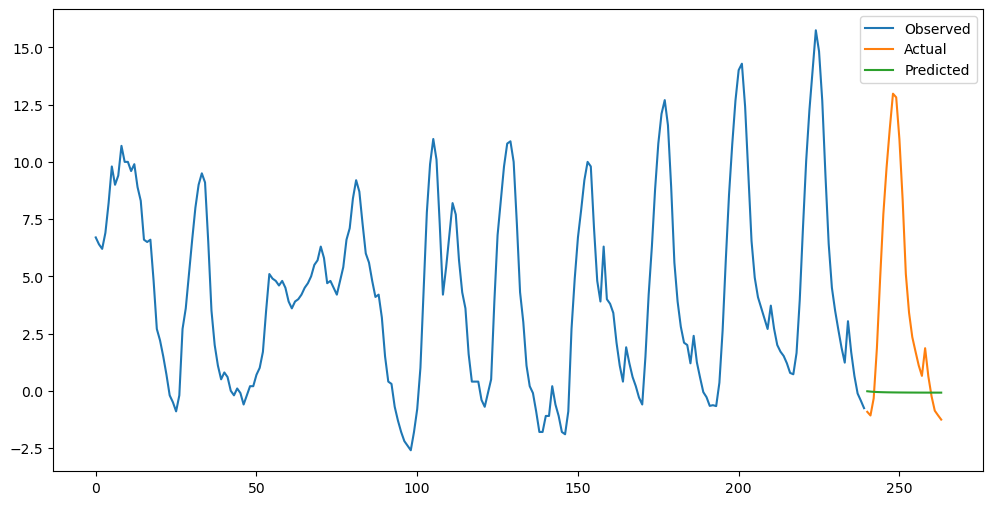

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
[0.64557767 0.1939746 ]


In [30]:
# ECVs, Meta-Prediction
# ---

# input
# -----
print("file_model_backbone", file_model_backbone)
print("file_model_fitted",   file_model_fitted)
backbone = keras.models.load_model(file_model_backbone)
model    = keras.models.load_model(file_model_fitted)

print("file_inpput_dataset", file_inpput_dataset)
with open(file_inpput_dataset, 'rb') as fp_inp:
    inp_data = pickle.load(fp_inp)
    # X_train
    # Y_train
    # x_support
    # y_support


# start
# -----
# check model accuracy, temperature
# .....
test_idx = -16

pred_x    = model.predict(np.array([X_train[test_idx]]))
temp_x    = np.transpose(X_train[test_idx])[3]  # Observed

pred_temp = np.transpose(pred_x[0])[3]          # Predicted
true_temp = np.transpose(Y_train[test_idx])[3]  # Actual

plt.figure(figsize=(12, 6))
plt.plot( range(0,                          len(temp_x)), temp_x,    label='Observed')
plt.plot( range(len(temp_x), len(temp_x)+len(true_temp)), true_temp, label='Actual')
plt.plot( range(len(temp_x), len(temp_x)+len(pred_temp)), pred_temp, label='Predicted')
plt.legend()
plt.show()

# Vector Space Exploration
# .....
from sklearn.decomposition import PCA

train_labels = [c[0] for c in y_support]
x_representation = backbone.predict(x_support)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_representation)

print(pca.explained_variance_ratio_)